# LECTURE 15
**Topic:** Signal Transformations and the DFT; Duality; Circular Symmetry Revisited  
**Textbook References:** Sections 3.4, 3.5

---

## Key Points

| Time Domain | Frequency Domain |
|---|---|
| $P^m x$ | $F^{-m}X = F^{N-m}X$ |
| $F^m x$ | $P^m X$ |
| $X$ | $NRx$ |

- **DFT 5:** Circular shift by $m$ in time $\leftrightarrow$ multiply by $(N-m)$-th Fourier sinusoid in frequency.
- **DFT 6:** Multiply by $m$-th Fourier sinusoid in time $\leftrightarrow$ circular shift by $m$ in frequency.
- **DFT 7 (Duality):** If $x\leftrightarrow X$, then $X\leftrightarrow NRx$.
- Real and circularly symmetric signal $\Rightarrow$ real and circularly symmetric spectrum.


---
## Theory and Examples

### 1. Shifts of V Rows and Columns

Using $V=[1\;F1\;F^21\;\cdots\;F^{N-1}1]$ (columns formed by applying powers of $F$ to the all-ones vector):

$$VP^m = F^mV \qquad P^mV = VF^{-m}$$
$$WP^m = F^{-m}W \qquad P^mW = WF^m$$

### 2–3. DFT 5 & 6

**DFT 5:** $y=P^mx \Rightarrow Y=WP^mx=F^{-m}Wx=F^{-m}X=F^{N-m}X$

**DFT 6:** $y=F^mx \Rightarrow Y=WF^mx=P^mWx=P^mX$

These are **duals** of each other: circular shift ↔ multiply by sinusoid.

### 4. Example with 6-point DFT pairs

If $[a,b,c,d,e,f]^T \leftrightarrow [A,B,C,D,E,F]^T$, then:
- $[d,e,f,a,b,c]^T = P^3x \leftrightarrow F^{-3}X = F^3X$ (since $F^{N-3}=F^3$ for $N=6$)
  The diagonal of $F^3$ is $[1,e^{j\pi},e^{j2\pi},\ldots]=[1,-1,1,-1,1,-1]$, so $F^{N/2}X=[A,-B,C,-D,E,-F]^T$
- $[a,-b,c,-d,e,-f]^T = F^{N/2}x \leftrightarrow P^3X=[D,E,F,A,B,C]^T$


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def make_P(N):
    P=np.zeros((N,N)); P[0,N-1]=1
    for i in range(1,N): P[i,i-1]=1
    return P
def make_R(N):
    R=np.zeros((N,N)); R[0,0]=1
    for i in range(1,N): R[i,N-i]=1
    return R
def make_F(N,k=1):
    v=np.exp(1j*2*np.pi/N)
    return np.diag([v**(k*n) for n in range(N)])

N=6
np.random.seed(3)
x=np.random.randn(N)+1j*np.random.randn(N)
X=np.fft.fft(x)
P6=make_P(N); R6=make_R(N)

print('=== Verify DFT 5: P^m x <-> F^(-m) X ===')
for m in [1,2,3]:
    Pm=np.linalg.matrix_power(P6,m)
    Fm_neg=make_F(N,-m)
    Y_fft=np.fft.fft(Pm@x)
    Y_formula=(Fm_neg@X)
    print(f'  m={m}: match={np.allclose(Y_fft,Y_formula)}')

print('\n=== Verify DFT 6: F^m x <-> P^m X ===')
for m in [1,2,3]:
    Fm=make_F(N,m)
    Pm=np.linalg.matrix_power(P6,m)
    Y_fft=np.fft.fft(Fm@x)
    Y_formula=Pm@X
    print(f'  m={m}: match={np.allclose(Y_fft,Y_formula)}')

=== Verify DFT 5: P^m x <-> F^(-m) X ===
  m=1: match=True
  m=2: match=True
  m=3: match=True

=== Verify DFT 6: F^m x <-> P^m X ===
  m=1: match=True
  m=2: match=True
  m=3: match=True


In [2]:
# Concrete example: 6-point DFT pair
a,b,c,d,e,f = 1.0,2.0,-1.0,3.0,0.5,-2.0
x6=np.array([a,b,c,d,e,f])
X6=np.fft.fft(x6)
A,B,C,D,E,F2=X6
print('x = [a,b,c,d,e,f] =',x6)
print('X = [A,B,C,D,E,F] =',X6.round(4))

# [d,e,f,a,b,c] = P^3 x  <->  F^(-3)X = F^3 X (N=6, F^3=diag(1,-1,1,-1,1,-1))
x_shift3=np.array([d,e,f,a,b,c])
Y_shift3=np.fft.fft(x_shift3)
Y_formula3=np.array([A,-B,C,-D,E,-F2])
print(f'\n[d,e,f,a,b,c] -> fft={Y_shift3.round(4)}')
print(f'  [A,-B,C,-D,E,-F] =     {Y_formula3.round(4)}')
print(f'  match={np.allclose(Y_shift3,Y_formula3)}')

# [a,-b,c,-d,e,-f] = F^3 x  <->  P^3 X = [D,E,F,A,B,C]
x_mod=np.array([a,-b,c,-d,e,-f])
Y_mod=np.fft.fft(x_mod)
Y_formula_mod=np.array([D,E,F2,A,B,C])
print(f'\n[a,-b,c,-d,e,-f] -> fft={Y_mod.round(4)}')
print(f'  [D,E,F,A,B,C] =         {Y_formula_mod.round(4)}')
print(f'  match={np.allclose(Y_mod,Y_formula_mod)}')

# Third pair from lecture: [2a,b,-c,-2d,-e,f] <-> [F+B, A+C, B+D, C+E, D+F, E+A]
# This is x + P^(-1)x... let's derive
# Actually from lecture: need to think through
# x^(3) in example: check what 2a,b,-c,-2d,-e,f comes from
# This looks like x + modified x. Let's just verify with fft
x_c3=np.array([2*a,b,-c,-2*d,-e,f])
Y_c3=np.fft.fft(x_c3)
Y_expected_c3=np.array([F2+B,A+C,B+D,C+E,D+F2,E+A])
print(f'\n[2a,b,-c,-2d,-e,f] -> fft={Y_c3.round(4)}')
print(f'  [F+B,A+C,B+D,C+E,D+F,E+A]={Y_expected_c3.round(4)}')
print(f'  match={np.allclose(Y_c3,Y_expected_c3)}')

x = [a,b,c,d,e,f] = [ 1.   2.  -1.   3.   0.5 -2. ]
X = [A,B,C,D,E,F] = [ 3.5 +0.j     -1.75-2.1651j  4.25-4.7631j -2.5 +0.j      4.25+4.7631j
 -1.75+2.1651j]

[d,e,f,a,b,c] -> fft=[3.5 +0.j     1.75+2.1651j 4.25-4.7631j 2.5 -0.j     4.25+4.7631j
 1.75-2.1651j]
  [A,-B,C,-D,E,-F] =     [3.5 +0.j     1.75+2.1651j 4.25-4.7631j 2.5 -0.j     4.25+4.7631j
 1.75-2.1651j]
  match=True

[a,-b,c,-d,e,-f] -> fft=[-2.5 +0.j      4.25+4.7631j -1.75+2.1651j  3.5 -0.j     -1.75-2.1651j
  4.25-4.7631j]
  [D,E,F,A,B,C] =         [-2.5 +0.j      4.25+4.7631j -1.75+2.1651j  3.5 +0.j     -1.75-2.1651j
  4.25-4.7631j]
  match=True

[2a,b,-c,-2d,-e,f] -> fft=[-3.5 +0.j      7.75-4.7631j -4.25-2.1651j  8.5 +0.j     -4.25+2.1651j
  7.75+4.7631j]
  [F+B,A+C,B+D,C+E,D+F,E+A]=[-3.5 -0.j      7.75-4.7631j -4.25-2.1651j  8.5 +0.j     -4.25+2.1651j
  7.75+4.7631j]
  match=True


---
### 7. DFT 7: Duality

If $x\leftrightarrow X$, then $X\leftrightarrow NRx$.

**Proof:** $Y=Wy=WX=RVX=NRx$ (using $WV=RVV/N\cdot N$... more precisely: $WX=W(Wx)=V^*W x$... actually: $WX=W\cdot(Wx)=VRWx=NRx$ using $W=RV$ and $VV^*=VI=NI$... let's write it cleanly).

$Y=Wy=WX=R\underbrace{VX}_{Ns}=NRx\quad$ (since $W=RV$ and $VX=Ns$).

**Example:** If $[a,b,c,d,e,f]^T\leftrightarrow[3,1-j,2+j,-1,2-j,1+j]^T$, then:
$$[3,1-j,2+j,-1,2-j,1+j]^T \leftrightarrow 6[a,f,e,d,c,b]^T$$

### 8–10. Circular Symmetry and Real-Valued Signals

- $x=x^*$ (real) $\Rightarrow X=RX^*$ (circular conjugate symmetry)
- $x=Rx^*$ $\Rightarrow X=X^*$ (real spectrum)
- $x=x^*=Rx$ (real and circularly symmetric) $\Rightarrow X=X^*=RX$ (real and circularly symmetric)


DFT 7: X <-> N*R*x
fft(X)   = [ 13.9956+0.j   2.5232+0.j  -4.293 +0.j  -2.5571+0.j  -0.0663+0.j
 -21.2265+0.j  -3.8765+0.j  -2.2886+0.j]
N*R*x    = [ 13.9956   2.5232  -4.293   -2.5571  -0.0663 -21.2265  -3.8765  -2.2886]
Match? True

Real and circularly symmetric x: [-1.  3.  2.  1.  4.  1.  2.  3.]
Rx = [-1.  3.  2.  1.  4.  1.  2.  3.]  (= x? True)
X = [15.    +0.j -2.1716+0.j -1.    +0.j -7.8284+0.j -1.    +0.j -7.8284+0.j
 -1.    +0.j -2.1716+0.j]
X is real? True
X = RX? True


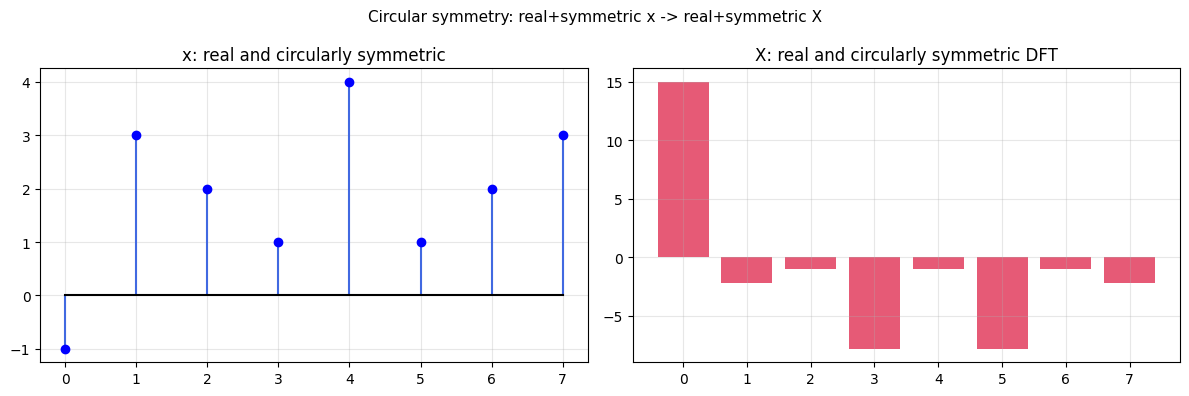

In [3]:
# Verify DFT 7 duality
np.random.seed(11)
N=8
x8=np.random.randn(N)
X8=np.fft.fft(x8)
R8=make_R(N)

Y_formula=N*(R8@x8)
Y_fft=np.fft.fft(X8)
print('DFT 7: X <-> N*R*x')
print(f'fft(X)   = {Y_fft.round(4)}')
print(f'N*R*x    = {Y_formula.round(4)}')
print(f'Match? {np.allclose(Y_fft, Y_formula)}')

# Real and circularly symmetric example from lecture
x_sym=np.array([-1,3,2,1,4,1,2,3], dtype=float)
X_sym=np.fft.fft(x_sym)
print(f'\nReal and circularly symmetric x: {x_sym}')
print(f'Rx = {R8@x_sym}  (= x? {np.allclose(R8@x_sym, x_sym)})')
print(f'X = {X_sym.round(4)}')
print(f'X is real? {np.allclose(X_sym.imag, 0)}')
print(f'X = RX? {np.allclose(X_sym, R8@X_sym)}')

# Plot the symmetric signal and its real DFT
fig, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].stem(range(N), x_sym, linefmt='royalblue', markerfmt='bo', basefmt='k')
axes[0].set_title('x: real and circularly symmetric'); axes[0].grid(True,alpha=0.3)
axes[1].bar(range(N), X_sym.real, color='crimson', alpha=0.7)
axes[1].set_title('X: real and circularly symmetric DFT'); axes[1].grid(True,alpha=0.3)
plt.suptitle('Circular symmetry: real+symmetric x -> real+symmetric X', fontsize=11)
plt.tight_layout(); plt.show()

---
## Summary of DFT Properties

| # | Property | Time | Frequency |
|---|---|---|---|
| DFT 1 | Linearity | $\alpha x+\beta y$ | $\alpha X+\beta Y$ |
| DFT 2 | Real signal | $x=x^*$ | $X=RX^*$ |
| DFT 3 | Conjugation | $x^*$ | $RX^*$ |
| DFT 4 | Reversal | $Rx$ | $RX$ |
| DFT 5 | Circular shift | $P^mx$ | $F^{N-m}X$ |
| DFT 6 | Modulation | $F^mx$ | $P^mX$ |
| DFT 7 | Duality | $X$ | $NRx$ |

### Mistakes to Avoid
1. DFT 5 and DFT 6 are **duals** — shift↔modulation. Don't mix up which is which.
2. In DFT 7: $X\leftrightarrow NRx$ (reversed AND scaled by $N$).
3. Circular symmetry ($Rx=x$) is different from even symmetry ($x[-n]=x[n]$ in CT). Index 0 is fixed, other entries are mirrored.
